In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# -----------------------------
# 1. Load Data
# -----------------------------
df = pd.read_csv("/Users/shubhangipanda/Documents/Projects/ml-pipelines/data/raw/Churn.csv")

In [12]:
df = df.fillna(0)

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
# -----------------------------
# 2. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# 3. Train Model
# -----------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
# 4. Evaluate Model
# -----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7927608232789212

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



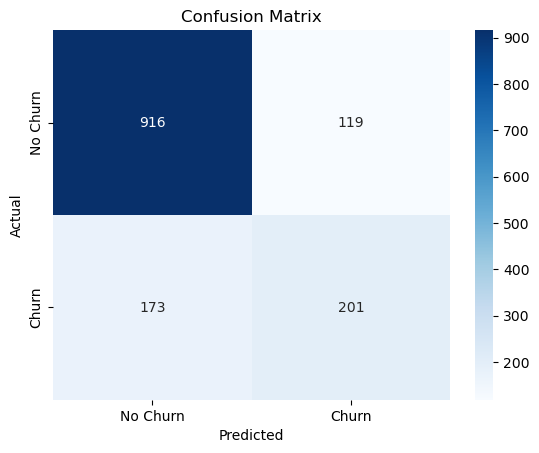

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)


In [22]:
# -----------------------------
# 2. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((5634, 19), (1409, 19), 0.2653532126375577, 0.2654364797728886)

In [27]:
# --------------------------------------------------------
# Step 2) Train Random Forest model
# --------------------------------------------------------
# Random Forest = collection of decision trees (ensemble)
# - n_estimators = number of trees
# - class_weight="balanced" → useful if dataset is imbalanced

rf = RandomForestClassifier(
    n_estimators=200,         # number of trees
    max_depth=None,          # let trees grow; we’ll tune later
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    class_weight="balanced"  # handle class imbalance (churn usually has fewer 1s)
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [26]:
# --------------------------------------------------------
# Step 3) Evaluate model performance
# --------------------------------------------------------
# predictions on test data
y_pred = rf.predict(X_test)

# predicted probabilities (needed for ROC-AUC)
y_prob = rf.predict_proba(X_test)[:, 1]

# evaluation metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7842
Precision: 0.6224
Recall   : 0.4759
F1 Score : 0.5394
ROC-AUC  : 0.8194

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



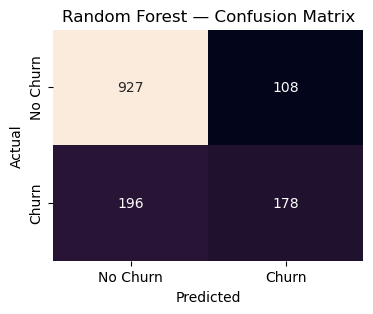

In [28]:
# --------------------------------------------------------
# Step 4) Confusion Matrix (visual)
# --------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cbar=False,
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

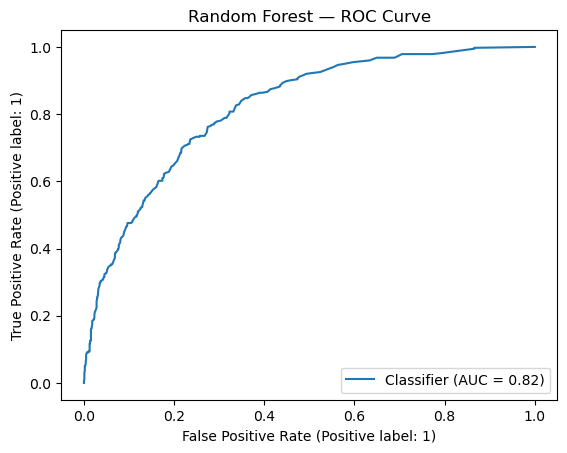

In [29]:
# --------------------------------------------------------
# Step 5) ROC Curve (visual)
# --------------------------------------------------------
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Random Forest — ROC Curve")
plt.show()

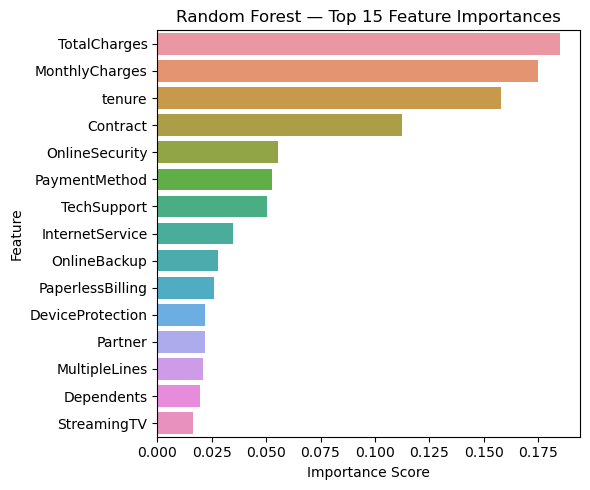

TotalCharges        0.184930
MonthlyCharges      0.174986
tenure              0.157662
Contract            0.112220
OnlineSecurity      0.055509
PaymentMethod       0.052905
TechSupport         0.050428
InternetService     0.034954
OnlineBackup        0.028058
PaperlessBilling    0.025948
DeviceProtection    0.022065
Partner             0.021752
MultipleLines       0.021091
Dependents          0.019546
StreamingTV         0.016312
dtype: float64

In [30]:
# --------------------------------------------------------
# Step 6) Feature Importance
# --------------------------------------------------------
# Random Forest gives importance of each feature
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

# take top 15 most important features
topk = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6,5))
sns.barplot(x=topk.values, y=topk.index)
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

topk

In [31]:
# --------------------------------------------------------
# Step 7) Save the trained model
# --------------------------------------------------------
import os, joblib

# make models/ folder if not exists
os.makedirs("models", exist_ok=True)

# save model as .pkl (pickle format)
joblib.dump(rf, "models/churn_rf_model.pkl")

print("Model saved at: models/churn_rf_model.pkl")

Model saved at: models/churn_rf_model.pkl


In [32]:
from sklearn.metrics import roc_auc_score

# Predict probabilities for the positive class (churn = 1)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.819394714407502
